In [6]:
#@title xlsxファイルをdfとして読み込み
import pandas as pd

# Load the Excel file into a pandas DataFrame
df = pd.read_excel('/content/練習収益.xlsx')

# Display the first 5 rows of the DataFrame
display(df.head())

,Unnamed: 0,4月,5月,6月,7月,8月,9月
0,社会保険請求収入,5000,5272,6289,4837,5693,5743
1,社会保健窓口収入,193,174,181,227,237,268
2,自由診療収入,251,272,133,577,603,541
3,医業収益,2279,2176,2982,2301,2544,2222
4,医業利益,286,116,294,372,123,145


In [8]:
#@title グラフの日本語表示のためのモジュールのインストール

# Install a Japanese font for matplotlib
!pip install japanize-matplotlib --quiet

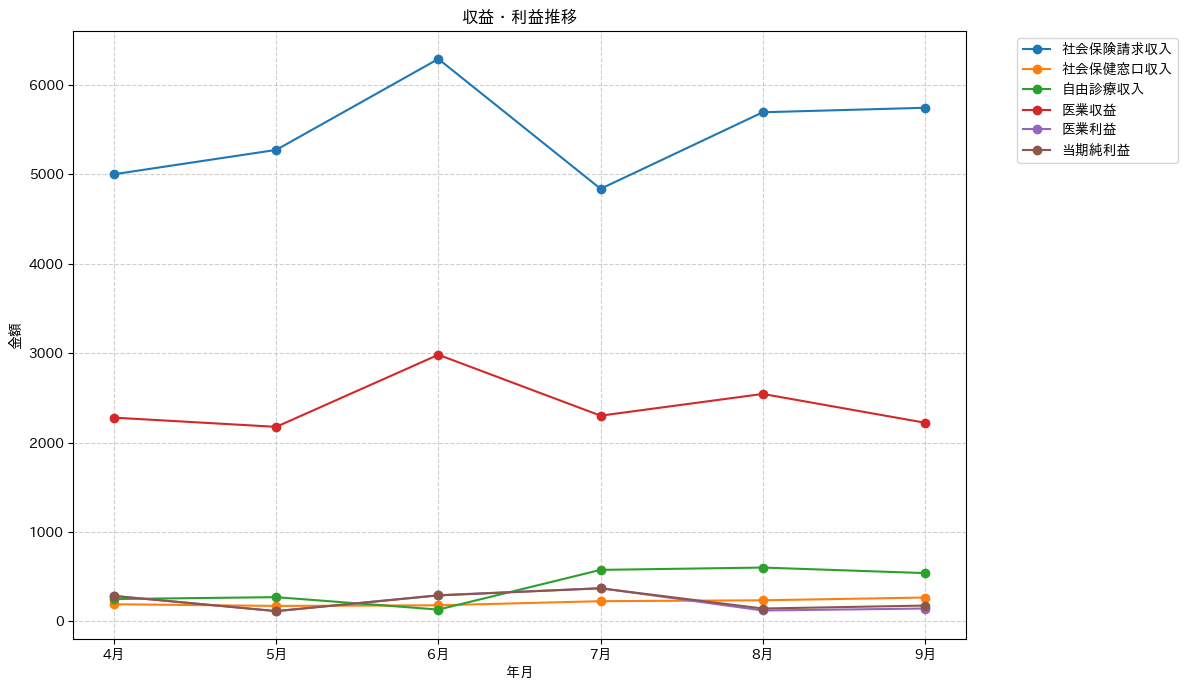

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # 日本語表示用

# 1. データの読み込み
# インデックス（行名）として1列目（項目名）を指定します
df_raw = pd.read_excel('練習収益.xlsx', index_col=0)

# 行（項目）と列（月）を入れ替えて、横軸を「年月」にします
df = df_raw.transpose()
df.index.name = '年月'

# カンマが含まれる場合に備えて数値に変換（必要に応じて）
for col in df.columns:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

# 2. グラフの作成
plt.figure(figsize=(12, 7))

# 指定された項目を折れ線グラフで描画
target_columns = [
    '社会保険請求収入', '社会保健窓口収入', '自由診療収入',
    '医業収益', '医業利益', '当期純利益'
]

for column in target_columns:
    if column in df.columns:
        plt.plot(df.index, df[column], marker='o', label=column)

# 3. グラフの装飾
plt.title('収益・利益推移')
plt.xlabel('年月')
plt.ylabel('金額')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # 凡例を表示
plt.tight_layout()

# 保存と表示
plt.savefig('profit_trend_chart.png')
plt.show()

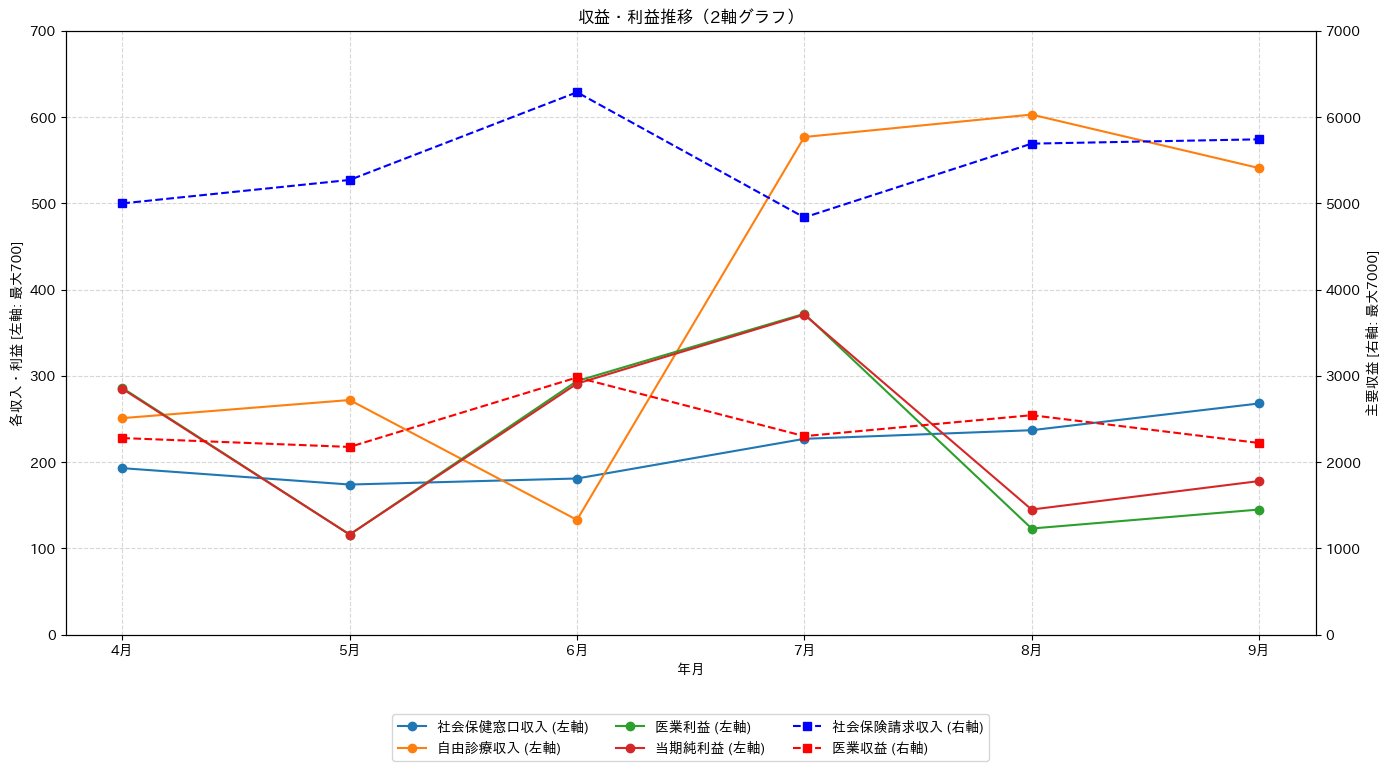

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

# 1. データの読み込みと整形
# ファイル名「練習収益」を参照
df_raw = pd.read_excel('練習収益.xlsx', index_col=0)
df = df_raw.transpose()
df.index.name = '年月'

# カンマ削除と数値型への変換[cite: 2]
for col in df.columns:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

# 2. グラフの土台作成
fig, ax1 = plt.subplots(figsize=(14, 8))

# --- 右軸 (ax2): 社会保険請求収入、医業収益 ---
ax2 = ax1.twinx()
right_cols = ['社会保険請求収入', '医業収益'] #[cite: 2]
colors_right = ['blue', 'red']

for col, color in zip(right_cols, colors_right):
    if col in df.columns:
        ax2.plot(df.index, df[col], marker='s', linestyle='--', color=color, label=f'{col} (右軸)')

ax2.set_ylim(0, 7000) # 最大値を7000に設定
ax2.set_ylabel('主要収益 [右軸: 最大7000]')

# --- 左軸 (ax1): それ以外の項目 ---
# 右軸以外の項目を抽出[cite: 2]
left_cols = ['社会保健窓口収入', '自由診療収入', '医業利益', '当期純利益']

for col in left_cols:
    if col in df.columns:
        ax1.plot(df.index, df[col], marker='o', label=f'{col} (左軸)')

ax1.set_ylim(0, 700) # 最大値を700に設定
ax1.set_ylabel('各収入・利益 [左軸: 最大700]')
ax1.set_xlabel('年月')

# 3. 凡例の結合と配置（下部に表示）
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)

plt.title('収益・利益推移（2軸グラフ）')
ax1.grid(True, linestyle='--', alpha=0.5)

# レイアウト調整と保存
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.savefig('revenue_dual_axis_7000_700.png', dpi=300)
plt.show()

    社会保健窓口収入  自由診療収入  医業利益  当期純利益
年月                               
4月       193     251   286    285
5月       174     272   116    116
6月       181     133   294    291
7月       227     577   372    371
8月       237     603   123    145


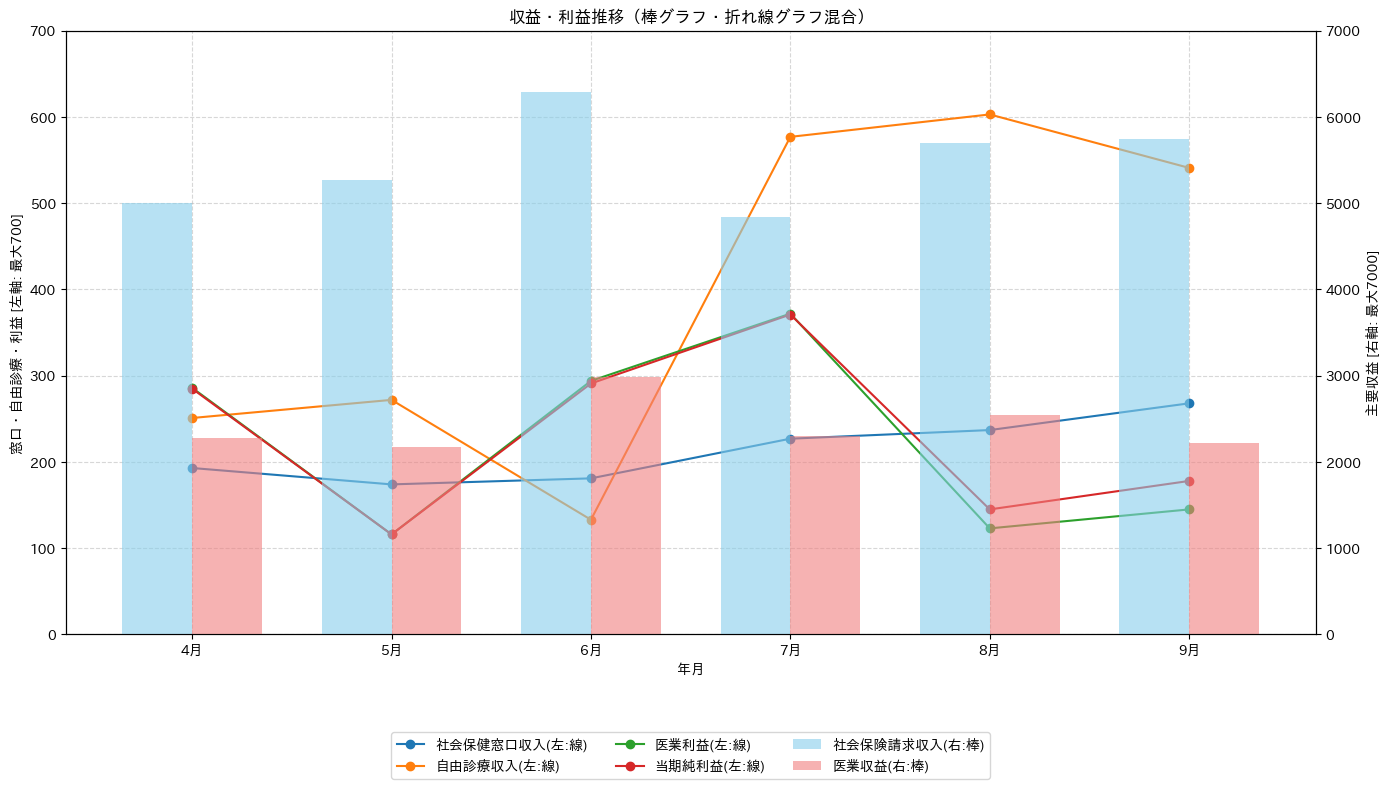

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

# 1. データの読み込みと整形
# ファイル「練習収益」を読み込み
df_raw = pd.read_excel('練習収益.xlsx', index_col=0)
df = df_raw.transpose()
df.index.name = '年月'

# 数値データのクリーニング（カンマを除去して確実に数値型に変換）
for col in df.columns:
    # 文字列としてカンマを除去してから数値化し、変換できないものは欠損値(NaN)にする
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

# データが正しく数値化されているか確認（デバッグ用）
print(df[['社会保健窓口収入', '自由診療収入', '医業利益', '当期純利益']].head())

# 2. グラフの作成
fig, ax1 = plt.subplots(figsize=(14, 8))

# --- 右軸 (ax2): 棒グラフ（社会保険請求収入、医業収益） ---
ax2 = ax1.twinx()
x = range(len(df.index))
width = 0.35

# データの存在確認をしてから描画
if '社会保険請求収入' in df.columns and '医業収益' in df.columns:
    ax2.bar([p - width/2 for p in x], df['社会保険請求収入'], width=width, label='社会保険請求収入(右:棒)', color='skyblue', alpha=0.6)
    ax2.bar([p + width/2 for p in x], df['医業収益'], width=width, label='医業収益(右:棒)', color='lightcoral', alpha=0.6)

ax2.set_ylim(0, 7000)
ax2.set_ylabel('主要収益 [右軸: 最大7000]')

# --- 左軸 (ax1): 折れ線グラフ（窓口収入、自由診療、利益、純利益） ---
# 元データの表記「社会保健窓口収入」に合わせています[cite: 2]
left_line_cols = ['社会保健窓口収入', '自由診療収入', '医業利益', '当期純利益']
for col in left_line_cols:
    if col in df.columns:
        # データの欠損を除いてプロット
        ax1.plot(df.index, df[col], marker='o', label=f'{col}(左:線)')

ax1.set_ylim(0, 700)
ax1.set_ylabel('窓口・自由診療・利益 [左軸: 最大700]')
ax1.set_xlabel('年月')

# 3. 凡例の結合と位置調整（グラフの下）
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

plt.title('収益・利益推移（棒グラフ・折れ線グラフ混合）')
ax1.grid(True, linestyle='--', alpha=0.5)

# レイアウト調整とPNG保存
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.savefig('profit_mixed_chart.png', dpi=300)
plt.show()